## This notebook integrates two AI agents:
1. **Rule Extraction Agent**: Extracts SBVR rules from new policy documents
2. **MCP GitHub Agent**: Fetches current rule configuration from GitHub and performs impact analysis

## Prerequisites:
1. GitHub Personal Access Token (for MCP GitHub integration)
2. OpenAI API Key
3. A GitHub repository with current policy rules configuration

In [1]:
import os
import re
import json
from typing import TypedDict, List, Annotated, Dict, Any
import operator

from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
# LangChain MCP Adapter for GitHub integration
from langchain_mcp_adapters.client import MultiServerMCPClient


## 1. Define Enhanced State

Compared to the original agent, we need to track more information throughout the workflow:

In [2]:
class PolicyImpactAnalysisState(TypedDict):
    """Enhanced state for multi-workflow routing system"""
    # Conversation history
    messages: Annotated[List[BaseMessage], operator.add]
    
    # Current rules from GitHub repository (used in Impact Analysis workflow)
    current_rules: List[Dict[str, Any]]
    
    # New extracted rules from latest policy documents (used in Workflow 4)
    new_rules: List[Dict[str, Any]]
    
    # Impact analysis report (used in Impact Analysis workflow)
    impact_report: str
    
    # Workflow routing flag - which workflow to execute
    workflow_type: str  # "rule_extraction" | "impact_analysis" | "qa" | "impact_and_update"
    
    # User's original query
    user_query: str

    # SHA of the current file in the GitHub repository
    current_file_sha: str
    
    # Change statistics for smart routing decisions
    change_stats: Dict[str, int]

    # Context passed from analysis to update node
    analysis_context: Dict[str, Dict[str, str]]


    debug_queries: List[Dict[str, str]]

print("✅ PolicyImpactAnalysisState defined with workflow routing support")

✅ PolicyImpactAnalysisState defined with workflow routing support


## 2. Build the Toolbox

### Tool 1 & 2: Original SBVR Extraction and General QA Tools

In [3]:
# Import from the same directory (Agent 1)
from localsearch_engine_builder import build_search_engine

# Configure paths - adjusted for Agent 1 folder
INDEX_ROOT = os.path.join("..", "GraphRAG result", "kyc_workflow", "output")
QA_PROMPT_PATH = os.path.join("system_prompt", "cust_local_search_system_prompt.txt")
SBVR_PROMPT_PATH = os.path.join("system_prompt", "sbvr_local_search_system_prompt.txt")

# Build SBVR extraction engine
print("🔧 Building SBVR Extraction engine...")
sbvr_engine = build_search_engine(
    index_root=INDEX_ROOT,
    system_prompt_path=SBVR_PROMPT_PATH,
    response_type="Return SBVR-style business rules in strict JSON format."
)

# Build general QA engine
print("🔧 Building General QA engine...")
qa_engine = build_search_engine(
    index_root=INDEX_ROOT,
    system_prompt_path=QA_PROMPT_PATH,
    response_type="multiple paragraphs"
)

print("✅ Search engines ready!")


🔧 Building SBVR Extraction engine...
🔧 Building General QA engine...
✅ Search engines ready!


In [4]:
from pydantic import BaseModel, Field
from typing import Literal, Optional, List

class ImpactAnalysisResult(BaseModel):
    original_rule_id: str = Field(description="The ID of the baseline rule being analyzed")
    status: Literal["UNCHANGED", "MODIFIED", "DELETED"]
    latest_source_reference: Optional[str] = None
    latest_clause_reference: Optional[str] = None
    change_analysis: str

class SBVRRule(BaseModel):
    """Pydantic model for a complete SBVR rule, strictly following the specified format."""
    id: str = Field(description="Internal rule ID (e.g., 'CDD-R-001'). Generate a short, stable ID if not present.")
    source_reference: str = Field(description="Human-readable source, including doc_title/version/section_title/author when available.")
    clause_reference: Optional[str] = Field(None, description="The specific clause or section, e.g., '3.3', '3.3–3.5', or '3.3, 3.4'.")
    data_support: Optional[str] = Field(None, description="String listing supporting data tables and record IDs, using the [Data: ...] convention.")
    subject: str = Field(description="Who the rule applies to (e.g., 'authorized institution', 'staff').")
    modality: Literal["obligation", "prohibition", "permission", "recommendation"] = Field(description="The type of rule.")
    condition: Optional[str] = Field(None, description="Describes WHEN or IF the rule is triggered.")
    action: str = Field(description="Concise high-level summary of what must/must not/may/should be done.")
    action_steps: Optional[List[str]] = Field(None, description="A list of atomic action steps as stated in the text.")
    rationale: Optional[str] = Field(None, description="The purpose or rationale if explicitly stated in the text; otherwise null.")
    risk_level: Optional[Literal["high", "medium", "low"]] = Field(None, description="The risk level when clearly indicated; otherwise null.")
    tags: Optional[List[str]] = Field(None, description="An array of short keywords related to the rule.")


llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

comparison_llm = llm.with_structured_output(
    schema=ImpactAnalysisResult,
    method="json_schema",
)

rule_generation_llm = llm.with_structured_output(
    schema=SBVRRule,
    method="json_schema",
)

In [5]:
@tool
async def sbvr_extraction(question: str) -> str:
    """
    Extract SBVR-formatted rules from policy documents.
    Use this when user asks to "extract rules", "find obligations", "list requirements", etc.
    
    Args:
        question: Question about rule extraction
    
    Returns:
        JSON string containing list of rules
    """
    print("🔍 Executing SBVR rule extraction...")
    try:
        result = await sbvr_engine.search(question)
        return result.response  # Return JSON string
    except Exception as e:
        return json.dumps({"error": str(e), "rules": []})

@tool
async def general_qa(question: str) -> str:
    """
    Answer general questions about policies.
    Suitable for definitions, summaries, background information, etc.
    """
    print("💬 Executing general Q&A...")
    try:
        result = await qa_engine.search(question)
        return result.response
    except Exception as e:
        return f"Error: {e}"

### Tool 3: GitHub MCP Integration (LangChain Adapter - HTTP Transport)

**Using LangChain MCP Adapter with HTTP Transport** to connect to GitHub's cloud MCP service.

In [6]:
async def initialize_mcp_github_client():
    """Initialize MCP client using LangChain adapter and return GitHub tools"""
    github_token = os.environ.get("GITHUB_PERSONAL_ACCESS_TOKEN", "")
    
    if not github_token:
        print("⚠️ Warning: GITHUB_PERSONAL_ACCESS_TOKEN not set")
        return None, []
    
    try:
        client = MultiServerMCPClient({
            "github": {
                "transport": "http",
                "url": "https://api.githubcopilot.com/mcp/",
                "headers": {
                    "Authorization": f"Bearer {github_token}"
                }
            }
        })
        
        tools = await client.get_tools()
        print(f"✅ MCP GitHub Client initialized with {len(tools)} tools")
        # List available tools
        print("📋 Available GitHub tools:")
        for tool in tools:
            print(f"   - {tool.name}")
        
        return client, tools
    except Exception as e:
        print(f"❌ Failed to initialize MCP client: {e}")
        return None, []

# Initialize and get GitHub tools
mcp_github_client, github_mcp_tools = await initialize_mcp_github_client()

if mcp_github_client is not None:
    github_read_file_tool = next(
        (t for t in github_mcp_tools if t.name == "get_file_contents"),
        None
    )
    if github_read_file_tool is None:
        print("⚠️ get_file_contents tool not found")
else:
    github_mcp_tools = []
    github_read_file_tool = None
    print("⚠️ GitHub MCP tools not available")

@tool
async def fetch_current_policy_rules(owner: str, repo: str, file_path: str, branch: str = "main") -> Dict[str, Any]:
    """
    Fetch current policy rules configuration from GitHub repository using MCP Adapter.
    Returns a dictionary to update the graph's state, including the file's SHA.
    
    Args:
        owner: GitHub repository owner
        repo: Repository name
        file_path: Path to the rule configuration file
        branch: Branch name (default: main)
    
    Returns:
        Dictionary with:
        - 'current_rules': List of rules
        - 'current_file_sha': SHA of the fetched file (for safe updates)
        - 'error': Error message if failed
    """
    try:
        if not github_read_file_tool:
            raise Exception("GitHub MCP tools not initialized.")
        
        result = await github_read_file_tool.ainvoke({
            "owner": owner,
            "repo": repo,
            "path": file_path,
            "branch": branch
        })

        content = None
        file_sha = None
        
        if isinstance(result, list):
            for item in result:
                if isinstance(item, dict) and item.get('type') == 'text':
                    text = item.get('text', '')
                    
                    if 'successfully downloaded' in text.lower() and 'SHA:' in text:
                        sha_match = re.search(r'SHA:\s*([a-f0-9]{40})', text, re.IGNORECASE)
                        if sha_match:
                            file_sha = sha_match.group(1)
                    
                    elif text.strip().startswith('{') or text.strip().startswith('['):
                        content = text
        
        if not content:
            raise Exception("Could not extract file content from MCP response")
        
        rules_data = json.loads(content)
        current_rules = rules_data if isinstance(rules_data, list) else rules_data.get("rules", [])
        
        return {
            "current_rules": current_rules,
            "current_file_sha": file_sha or "",
            "error": None
        }
                    
    except json.JSONDecodeError as e:
        error_msg = f"Failed to parse JSON from GitHub: {str(e)}"
        print(f"❌ {error_msg}")
        return {
            "current_rules": [],
            "current_file_sha": "",
            "error": error_msg
        }
    except Exception as e:
        error_msg = f"Failed to fetch from GitHub: {str(e)}"
        print(f"❌ {error_msg}")
        return {
            "current_rules": [],
            "current_file_sha": "",
            "error": error_msg
        }

print("✅ GitHub MCP Client initialized")

✅ MCP GitHub Client initialized with 44 tools
📋 Available GitHub tools:
   - add_comment_to_pending_review
   - add_issue_comment
   - add_reply_to_pull_request_comment
   - assign_copilot_to_issue
   - create_branch
   - create_or_update_file
   - create_pull_request
   - create_pull_request_with_copilot
   - create_repository
   - delete_file
   - fork_repository
   - get_commit
   - get_copilot_job_status
   - get_file_contents
   - get_label
   - get_latest_release
   - get_me
   - get_release_by_tag
   - get_tag
   - get_team_members
   - get_teams
   - issue_read
   - issue_write
   - list_branches
   - list_commits
   - list_issue_types
   - list_issues
   - list_pull_requests
   - list_releases
   - list_tags
   - merge_pull_request
   - pull_request_read
   - pull_request_review_write
   - push_files
   - request_copilot_review
   - run_secret_scanning
   - search_code
   - search_issues
   - search_pull_requests
   - search_repositories
   - search_users
   - sub_issue_write


### Tool 4: Impact Analysis (Core Functionality)

In [7]:
@tool
async def analyze_policy_impact(rules: List[Dict[str, Any]]) -> Dict[str, Any]:
    """
    Analyze policy impact by validating each rule individually against latest documents.
    This new version uses a multi-agent approach for better accuracy.
    1. Query Generation Agent: Creates a search query from the rule.
    2. Retrieval Agent (qa_engine): Fetches latest context.
    3. Comparison Agent: Compares the rule against the fetched context.
    
    Args:
        rules: List of rule dictionaries from the graph's state
    
    Returns:
        Dictionary with 'impact_report' and 'analysis_context' keys.
    """
    try:
        current_rules = rules
        
        if not current_rules:
            return {
                "impact_report": json.dumps({"error": "No current rules provided"}),
                "analysis_context": {}
            }
        
        rule_count = len(current_rules)
        
        IMPACT_ANALYSIS_PROMPT_PATH = "system_prompt/impact_analysis_system_prompt.txt"
        with open(IMPACT_ANALYSIS_PROMPT_PATH, "r", encoding="utf-8") as f:
            comparison_system_prompt = f.read()

        validation_results = []
        analysis_context_data = {} # New: To store context for the update node
        
        for idx, rule in enumerate(current_rules, 1):
            rule_id = rule.get("id", f"UNKNOWN-{idx}")
            print(f"\n🔍 [{idx}/{rule_count}] Analyzing rule: {rule_id}")
            
            try:
                # 1. Query Generation Agent
                query_gen_prompt =  f"""
                You are a compliance retrieval query generator. Your goal is to create a simple, concise search question to find the latest policy for a given rule.

                Focus on the core topic by prioritizing:
                1. The 'condition' (the scenario)
                2. The 'action' (the high-level requirement)

                Query generation rules:
                - Extract the main topic. Avoid verbose descriptions.
                - Use simple, high-level wording. Do not copy jargon from the rule.
                - DO NOT include specific details like action steps, amounts, thresholds, dates, or clause numbers.
                - DO NOT include the rule ID or source references.
                - Keep the query to ONE short sentence.
                - Output ONLY the query text.

                Rule to process:
                {json.dumps(rule, ensure_ascii=False, indent=2)}

                Question:
                """
                response = await llm.ainvoke([HumanMessage(content=query_gen_prompt)])
                retrieval_query = response.content.strip()
                print(f"  - Generated Query: {retrieval_query}")

                # 2. Retrieval Agent (qa_engine)
                retrieved_context_result = await qa_engine.search(retrieval_query)
                retrieved_context = retrieved_context_result.response
                print(f"  - Retrieved Context: {len(retrieved_context)} characters")

                # 3. Comparison Agent (with Structured Output)
                comparison_prompt = f"""
                ---Topic---
                {retrieval_query}

                ---Baseline Rule---
                {json.dumps(rule, indent=2)}

                ---Latest Policy Context---
                {retrieved_context}

                """
                
                full_comparison_prompt = comparison_system_prompt.format(context_data=comparison_prompt)
                
                structured_response = await comparison_llm.ainvoke([HumanMessage(content=full_comparison_prompt)])
                
                validation_data = structured_response.model_dump()

                validation_results.append({
                    "rule_id": rule_id,
                    "analysis": validation_data,
                    "success": True
                })
                print("  - ✅ Analysis successful!")

                # New: Store context for the update node
                if validation_data.get("status") == "MODIFIED":
                    analysis_context_data[rule_id] = {
                        "retrieval_query": retrieval_query,
                        "retrieved_context": retrieved_context
                    }

            except Exception as e:
                error_detail = f"Error during analysis of rule {rule_id}: {str(e)}"
                print(f"  - ❌ {error_detail}")
                validation_results.append({
                    "rule_id": rule_id,
                    "analysis": {"error": error_detail},
                    "success": False
                })
        
        final_report = {
            "total_rules_analyzed": rule_count,
            "rules_analysis": validation_results
        }
        
        report_json = json.dumps(final_report, ensure_ascii=False, indent=2)
        
        return {
            "impact_report": report_json,
            "analysis_context": analysis_context_data
        }
            
    except Exception as e:
        error_msg = f"Error: Top-level impact analysis failed. Details: {str(e)}"
        print(f"❌ {error_msg}")
        return {
            "impact_report": json.dumps({"error": error_msg}),
            "analysis_context": {}
        }

print("✅ analyze_policy_impact tool defined")

✅ analyze_policy_impact tool defined


## 3. Multi-Workflow Routing System

### Router Node 

In [8]:
def router_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Router node: Analyze user intent and decide which workflow to execute.
    
    This node uses LLM to classify the user's query into one of four workflows:
    1. rule_extraction: Extract SBVR rules from policy documents (no GitHub update)
    2. impact_analysis: Fetch current rules from GitHub and analyze impact (no update)
    3. qa: Answer general questions about policies
    4. impact_and_update: Analyze impact AND update GitHub with new rules
    """
    print("\n" + "="*60)
    print("🧭 ROUTER: Analyzing user intent...")
    print("="*60)
    
    messages = state["messages"]
    user_query = messages[-1].content if messages else ""
    
    classification_prompt = f"""You are a workflow router. Analyze the user's query and classify it into ONE of these workflows:

1. **rule_extraction**: User wants to extract SBVR-formatted business rules from policy documents WITHOUT updating GitHub.
   - Keywords: "extract rules", "find obligations", "list requirements", "SBVR", "business rules"
   
2. **impact_analysis**: User wants to analyze the impact of policy changes WITHOUT updating GitHub.
   - Keywords: "impact analysis", "compare rules", "validate rules", "check changes", "policy impact"
   
3. **qa**: User has general questions about policies, definitions, or background information.
   - Keywords: "what is", "explain", "define", "tell me about", "summarize"

4. **impact_and_update**: User wants to analyze impact AND update GitHub repository with new rules based on latest policy documents.
   - Keywords: "update rules", "sync rules", "refresh policy", "update GitHub", "commit changes", "push new rules"

User Query: "{user_query}"

Respond with ONLY ONE WORD: rule_extraction, impact_analysis, qa, or impact_and_update"""

    response = llm.invoke([HumanMessage(content=classification_prompt)])
    workflow_type = response.content.strip().lower()
    
    valid_workflows = ["rule_extraction", "impact_analysis", "qa", "impact_and_update"]
    if workflow_type not in valid_workflows:
        workflow_type = "qa"
    
    print(f"✅ Workflow: {workflow_type}")
    
    return {
        "workflow_type": workflow_type,
        "user_query": user_query
    }

print("✅ router_node defined")

✅ router_node defined


### Workflow 1: SBVR Rule Extraction

In [9]:
async def rule_extraction_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 1: Extract SBVR rules from policy documents.
    This node calls the sbvr_extraction tool with the user's query.
    """
    print("\n" + "="*60)
    print("📋 WORKFLOW 1: SBVR Rule Extraction")
    print("="*60)
    
    user_query = state.get("user_query", "")
    result = await sbvr_extraction.ainvoke({"question": user_query})
    
    response_message = f"""✅ **SBVR Rule Extraction Complete**

{result}
"""
    
    return {
        "messages": [AIMessage(content=response_message)]
    }

print("✅ rule_extraction_node defined")

✅ rule_extraction_node defined


### Workflow 2: Impact Analysis (Step 1 - Fetch Rules)

In [10]:
async def impact_analysis_fetch_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 2 - Step 1: Fetch current rules from GitHub.
    Now also extracts and stores the file SHA for later updates.
    """
    print("\n" + "="*60)
    print("📥 WORKFLOW 2 - STEP 1: Fetching Rules from GitHub")
    print("="*60)
    
    owner = "JJchan123"
    repo = "compliance_rule_configuration"
    file_path = "policy_rules.json"
    branch = "main"
    
    result = await fetch_current_policy_rules.ainvoke({
        "owner": owner,
        "repo": repo,
        "file_path": file_path,
        "branch": branch
    })
    
    if result.get("error"):
        error_msg = f"❌ Failed to fetch rules: {result['error']}"
        print(error_msg)
        return {
            "messages": [AIMessage(content=error_msg)],
            "current_rules": [],
            "current_file_sha": ""
        }
    
    fetched_rules = result.get("current_rules", [])
    fetched_sha = result.get("current_file_sha", "")
    
    print(f"✅ Fetched {len(fetched_rules)} rules from GitHub")
    
    return {
        "current_rules": fetched_rules,
        "current_file_sha": fetched_sha
    }

print("✅ impact_analysis_fetch_node defined")

✅ impact_analysis_fetch_node defined


### Workflow 2: Impact Analysis (Step 2 - Current Rule(mcp) vs Latest Rule(Knowledge Graph))

In [11]:
async def impact_analysis_analyze_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 2 - Step 2: Analyze the impact of current rules.
    This node calls analyze_policy_impact and saves both the report and context to the state.
    """
    print("\n" + "="*60)
    print("📊 WORKFLOW 2 - STEP 2: Analyzing Policy Impact")
    print("="*60)
    
    current_rules = state.get("current_rules", [])
    
    if not current_rules:
        error_msg = "⚠️ Cannot analyze impact: no rules were fetched in previous step."
        print(error_msg)
        return {
            "impact_report": "Error: No rules available for analysis.",
            "analysis_context": {},
            "messages": [AIMessage(content=error_msg)]
        }
    
    # Call the analysis tool, which now returns a dict with two keys
    result = await analyze_policy_impact.ainvoke({"rules": current_rules})
    
    report = result.get("impact_report", "")
    analysis_context = result.get("analysis_context", {})
    
    final_message = f"""✅ **Impact Analysis Complete**

{report}

---
**Total Rules Analyzed**: {len(current_rules)}
"""
    
    return {
        "impact_report": report,
        "analysis_context": analysis_context, # Save context to state
        "messages": [AIMessage(content=final_message)]
    }

print("✅ impact_analysis_analyze_node defined")

✅ impact_analysis_analyze_node defined


### Workflow 3: General QA 

In [12]:
async def qa_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 3: Answer general questions about policies.
    This node calls the general_qa tool with the user's query.
    """
    print("\n" + "="*60)
    print("💬 WORKFLOW 3: General Q&A")
    print("="*60)
    
    user_query = state.get("user_query", "")
    
    # Call the QA tool
    result = await general_qa.ainvoke({"question": user_query})
    
    # Format the response
    response_message = f"""✅ **Answer**

{result}
"""
    
    return {
        "messages": [AIMessage(content=response_message)]
    }

print("✅ qa_node defined")

✅ qa_node defined


### Workflow 4: Impact & Update - Extract New Rules

In [13]:
async def extract_new_rules_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 4 - Step 3: Extract and update rules one by one based on impact analysis.
    Uses a guided, structured-output LLM for reliable updates.
    """
    print("\n" + "="*60)
    print("📋 WORKFLOW 4 - STEP 3: Extracting and Updating Rules (Refactored)")
    print("="*60)
    
    current_rules = state.get("current_rules", [])
    impact_report_json = state.get("impact_report", "")
    analysis_context = state.get("analysis_context", {}) # New: Get context from state
    
    if not current_rules:
        error_msg = "⚠️ No current rules available."
        print(error_msg)
        return {
            "new_rules": [],
            "change_stats": {"unchanged": 0, "modified": 0, "deleted": 0, "errors": 0},
            "messages": [AIMessage(content=error_msg)]
        }
    
    if not impact_report_json:
        error_msg = "⚠️ No impact report available."
        print(error_msg)
        return {
            "new_rules": [],
            "change_stats": {"unchanged": 0, "modified": 0, "deleted": 0, "errors": 0},
            "messages": [AIMessage(content=error_msg)]
        }
    
    try:
        impact_report = json.loads(impact_report_json)
        rules_analysis = impact_report.get("rules_analysis", [])
    except json.JSONDecodeError as e:
        error_msg = f"❌ Failed to parse impact report: {str(e)}"
        print(error_msg)
        return {
            "new_rules": [],
            "change_stats": {"unchanged": 0, "modified": 0, "deleted": 0, "errors": 0},
            "messages": [AIMessage(content=error_msg)]
        }
    
    analysis_map = {item.get("rule_id"): item.get("analysis", {}) for item in rules_analysis if item.get("success")}
    
    if not analysis_map:
        error_msg = "❌ No valid impact analysis available."
        print(error_msg)
        return {
            "new_rules": [],
            "change_stats": {"unchanged": 0, "modified": 0, "deleted": 0, "errors": 0},
            "messages": [AIMessage(content=error_msg)]
        }
    
    PER_RULE_UPDATE_PROMPT_PATH = "system_prompt/per_rule_update_prompt.txt"
    with open(PER_RULE_UPDATE_PROMPT_PATH, "r", encoding="utf-8") as f:
        per_rule_update_template = f.read()
    
    updated_rules = []
    stats = {"unchanged": 0, "modified": 0, "deleted": 0, "errors": 0}
    debug_queries = []

    for idx, rule in enumerate(current_rules, 1):
        rule_id = rule.get("id", f"UNKNOWN-{idx}")
        rule_analysis = analysis_map.get(rule_id, {})
        
        if not rule_analysis:
            updated_rules.append(rule)
            stats["errors"] += 1
            continue
        
        status = rule_analysis.get("status", "UNKNOWN")
        
        if status == "UNCHANGED":
            updated_rules.append(rule)
            stats["unchanged"] += 1
            continue
        
        if status == "DELETED":
            stats["deleted"] += 1
            continue
        
        if status == "MODIFIED":
            context_for_rule = analysis_context.get(rule_id)
            if not context_for_rule:
                print(f"⚠️ Missing context for modified rule {rule_id}. Skipping update.")
                updated_rules.append(rule)
                stats["errors"] += 1
                continue

            # New Refactored Logic
            try:
                rule_update_prompt = per_rule_update_template.format(
                    current_rule_json=json.dumps(rule, ensure_ascii=False, indent=2),
                    impact_analysis_json=json.dumps(rule_analysis, ensure_ascii=False, indent=2),
                    latest_policy_context=context_for_rule.get("retrieved_context", "")
                )
                
                debug_queries.append({"rule_id": rule_id, "query": rule_update_prompt})

                # Use the structured output LLM for guided generation
                structured_response = await rule_generation_llm.ainvoke([HumanMessage(content=rule_update_prompt)])
                
                # The response is a Pydantic object, convert to dict
                updated_rule = structured_response.model_dump()
                
                # Ensure the ID from the original rule is preserved
                updated_rule["id"] = rule_id
                updated_rules.append(updated_rule)
                stats["modified"] += 1
                print(f"  - ✅ Rule {rule_id} updated successfully.")

            except Exception as e:
                print(f"❌ Error updating rule {rule_id} with new method: {e}")
                updated_rules.append(rule) # Revert to original rule on error
                stats["errors"] += 1
        else:
            # For any other status, keep the original rule
            updated_rules.append(rule)
            stats["errors"] += 1
    
    print(f"\n📋 Summary: Processed={len(current_rules)}, Unchanged={stats['unchanged']}, Modified={stats['modified']}, Deleted={stats['deleted']}, Errors={stats['errors']}")
    
    has_changes = stats['modified'] > 0 or stats['deleted'] > 0
    
    if not has_changes:
        summary_message = f"""ℹ️ **No Changes Required**

**Processing Summary:**
- Total rules processed: {len(current_rules)}
- Unchanged: {stats['unchanged']}
- Modified: {stats['modified']}
- Deleted: {stats['deleted']}

✅ All rules are up-to-date with the latest policy documents.
No GitHub update is necessary.
"""
    else:
        summary_message = f"""✅ **Rule Update Complete**

**Processing Summary:**
- Total rules processed: {len(current_rules)}
- Unchanged: {stats['unchanged']}
- Modified: {stats['modified']}
- Deleted: {stats['deleted']}
- **Final rules count: {len(updated_rules)}**

**Changes Detected - Ready for GitHub Update**
"""
    
    return {
        "new_rules": updated_rules,
        "change_stats": stats,
        "messages": [AIMessage(content=summary_message)],
        "debug_queries": debug_queries
    }

print("✅ extract_new_rules_node defined")

✅ extract_new_rules_node defined


### Workflow 4: Impact & Update - Update to GitHub using LLM Agent

In [14]:
async def github_update_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Workflow 4 - Step 4: Update GitHub repository with new rules.
    Generates a detailed commit message for auditability.
    """
    print("\n" + "="*60)
    print("📤 WORKFLOW 4 - STEP 4: Updating GitHub Repository")
    print("="*60)
    
    new_rules = state.get("new_rules", [])
    current_sha = state.get("current_file_sha", "")
    change_stats = state.get("change_stats", {})
    impact_report_json = state.get("impact_report", "")
    
    if not new_rules:
        error_msg = "⚠️ No new rules to update."
        print(error_msg)
        return {"messages": [AIMessage(content=error_msg)]}
    
    owner = "JJchan123"
    repo = "compliance_rule_configuration"
    file_path = "policy_rules.json"
    branch = "main"
    
    new_content = json.dumps({"rules": new_rules}, indent=2, ensure_ascii=False)
    
    # --- New: Detailed Commit Message Generation ---
    modified_count = change_stats.get("modified", 0)
    deleted_count = change_stats.get("deleted", 0)
    
    # 1. Create the commit title
    commit_title = "Update policy rules"
    title_parts = []
    if modified_count > 0:
        title_parts.append(f"{modified_count} modified")
    if deleted_count > 0:
        title_parts.append(f"{deleted_count} deleted")
    if title_parts:
        commit_title += f": {', '.join(title_parts)}"
    else:
        commit_title += ": Sync" # Fallback for other changes

    # 2. Create the commit body
    commit_body_lines = []
    try:
        impact_report = json.loads(impact_report_json)
        rules_analysis = impact_report.get("rules_analysis", [])
        
        modified_rules = [
            item for item in rules_analysis 
            if item.get("success") and item.get("analysis", {}).get("status") == "MODIFIED"
        ]
        deleted_rules = [
            item for item in rules_analysis 
            if item.get("success") and item.get("analysis", {}).get("status") == "DELETED"
        ]

        if modified_rules:
            commit_body_lines.append("Modified Rules:")
            for item in modified_rules:
                rule_id = item.get('rule_id')
                analysis = item.get('analysis', {})
                change_desc = analysis.get('change_analysis', 'No analysis provided.')
                commit_body_lines.append(f"- {rule_id}: {change_desc}")
        
        if deleted_rules:
            if commit_body_lines: commit_body_lines.append("") # Add a separator line
            commit_body_lines.append("Deleted Rules:")
            for item in deleted_rules:
                rule_id = item.get('rule_id')
                commit_body_lines.append(f"- {rule_id}")

    except (json.JSONDecodeError, AttributeError) as e:
        print(f"⚠️ Could not generate detailed commit body: {e}")
        commit_body_lines.append("Automated update based on impact analysis.")

    commit_body = "\n".join(commit_body_lines)
    # --- End of New Logic ---

    github_write_tool = next(
        (t for t in github_mcp_tools if t.name == "create_or_update_file"),
        None
    )
    
    if not github_write_tool:
        error_msg = "❌ create_or_update_file tool not available"
        print(error_msg)
        return {"messages": [AIMessage(content=error_msg)]}
    
    tool_params = {
        "owner": owner,
        "repo": repo,
        "path": file_path,
        "content": new_content,
        "message": commit_title, # Use the new title
        "body": commit_body,     # Use the new body
        "branch": branch
    }
    
    if current_sha:
        tool_params["sha"] = current_sha
    
    try:
        result = await github_write_tool.ainvoke(tool_params)
        
        commit_sha = None
        commit_url = None
        
        if isinstance(result, list):
            for item in result:
                if isinstance(item, dict):
                    text = item.get('text', '')
                    
                    sha_match = re.search(r'commit.*?([a-f0-9]{40})', text, re.IGNORECASE)
                    if sha_match:
                        commit_sha = sha_match.group(1)
                    
                    url_match = re.search(r'(https://github\.com/[^\s]+)', text)
                    if url_match:
                        commit_url = url_match.group(1)
                        
        elif isinstance(result, str):
            commit_sha_match = re.search(r'commit.*?([a-f0-9]{40})', result, re.IGNORECASE)
            if commit_sha_match:
                commit_sha = commit_sha_match.group(1)
            
            url_match = re.search(r'(https://github\.com/[^\s]+)', result)
            if url_match:
                commit_url = url_match.group(1)
        
        success_msg = f"""✅ **GitHub Update Successful**

        **Repository**: {owner}/{repo}
        **File**: {file_path}
        **Branch**: {branch}
        **Commit Title**: {commit_title}
        """
        
        if commit_sha:
            success_msg += f"\n**Commit SHA**: {commit_sha}"
        
        if commit_url:
            success_msg += f"\n**Commit URL**: {commit_url}"
            
        if commit_body:
            success_msg += f"\n\n**Commit Details**:\n---\n{commit_body}"
        
        print("✅ GitHub update completed")
        
        return {"messages": [AIMessage(content=success_msg)]}
            
    except Exception as e:
        error_msg = f"❌ GitHub update failed: {str(e)}"
        print(error_msg)
        
        import traceback
        print(traceback.format_exc())
        
        return {"messages": [AIMessage(content=error_msg)]}


## 4. Build Routed Workflow Graph (with Workflow 4)

In [25]:
# Define routing function
def route_workflow(state: PolicyImpactAnalysisState) -> str:
    """
    Routing function: Decide which workflow to execute based on router's classification.
    """
    workflow_type = state.get("workflow_type", "qa")
    return workflow_type

# Define conditional routing after impact analysis
def should_update_rules(state: PolicyImpactAnalysisState) -> str:
    """
    Decide whether to proceed to rule extraction.
    Only extract rules if workflow type is 'impact_and_update'.
    """
    workflow_type = state.get("workflow_type", "")
    
    if workflow_type == "impact_and_update":
        return "extract_new_rules"
    else:
        return "end"

# Define conditional routing before GitHub commit
def should_commit_to_github(state: PolicyImpactAnalysisState) -> str:
    """
    Decide whether to commit to GitHub based on actual changes.
    Only commit if there are modified or deleted rules.
    """
    change_stats = state.get("change_stats", {})
    
    modified_count = change_stats.get("modified", 0)
    deleted_count = change_stats.get("deleted", 0)
    has_changes = modified_count > 0 or deleted_count > 0
    
    print(f"\n📊 Commit Decision: Modified={modified_count}, Deleted={deleted_count}")
    
    if has_changes:
        print("✅ Changes detected - Committing to GitHub")
        return "github_update"
    else:
        print("ℹ️  No changes - Skipping GitHub commit")
        return "end"

# Create state graph
workflow = StateGraph(PolicyImpactAnalysisState)

# Add all nodes
workflow.add_node("router", router_node)
workflow.add_node("rule_extraction", rule_extraction_node)
workflow.add_node("current_rules_fetch", impact_analysis_fetch_node)
workflow.add_node("impact_analysis", impact_analysis_analyze_node)
workflow.add_node("qa", qa_node)
workflow.add_node("extract_new_rules", extract_new_rules_node)
workflow.add_node("github_update", github_update_node)

# Define workflow structure
workflow.add_edge(START, "router")

# Conditional routing based on workflow_type
workflow.add_conditional_edges(
    "router",
    route_workflow,
    {
        "rule_extraction": "rule_extraction",
        "impact_analysis": "current_rules_fetch",
        "qa": "qa",
        "impact_and_update": "current_rules_fetch"
    }
)

workflow.add_edge("rule_extraction", END)
workflow.add_edge("current_rules_fetch", "impact_analysis")

workflow.add_conditional_edges(
    "impact_analysis",
    should_update_rules,
    {
        "extract_new_rules": "extract_new_rules",
        "end": END
    }
)

workflow.add_conditional_edges(
    "extract_new_rules",
    should_commit_to_github,
    {
        "github_update": "github_update",
        "end": END
    }
)

workflow.add_edge("github_update", END)
workflow.add_edge("qa", END)

# Compile the graph
app = workflow.compile()

print("✅ Multi-workflow routing graph compiled successfully!")

✅ Multi-workflow routing graph compiled successfully!


## 5. Visualize Multi-Workflow Graph

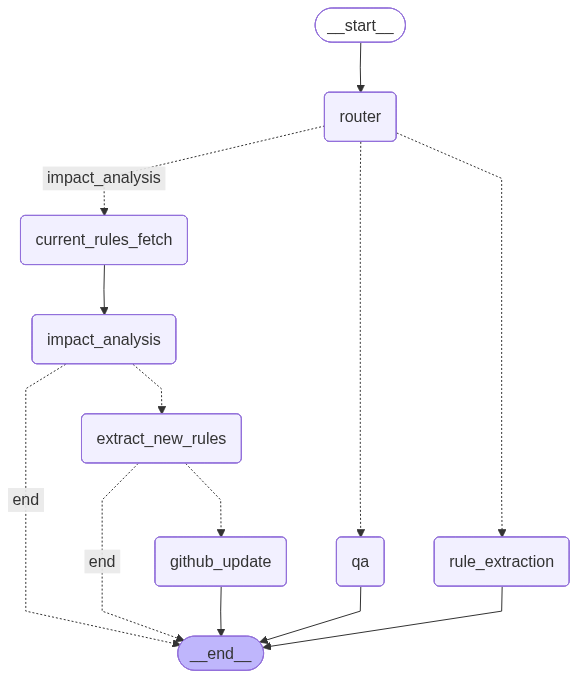

In [26]:
# Visualize graph structure if you have graphviz installed
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Cannot generate graph (graphviz required): {e}")

## 6. Run Multi-Workflow System

In [17]:
async def run_workflow(user_question: str):
    """
    Run the multi-workflow routing system with a user question.
    The router will automatically determine which workflow to execute.
    
    Args:
        user_question: User's question or request
    """
    print("🚀 Starting Multi-Workflow Routing System...")
    print("="*60)
    print(f"📝 User Question: {user_question}")
    print("="*60)
    
    # Create initial state
    initial_state = {
        "messages": [HumanMessage(content=user_question)],
        "current_rules": [],
        "new_rules": [],
        "impact_report": "",
        "workflow_type": "",
        "user_query": user_question,
        "current_file_sha": "",
        "change_stats": {"unchanged": 0, "modified": 0, "deleted": 0, "errors": 0},
        "analysis_context": {} # Initialize new state field
    }
    
    # Execute the workflow
    final_state = await app.ainvoke(initial_state)
    
    # Print final results
    print("\n" + "="*60)
    print("🎉 Workflow Execution Complete")
    print("="*60)
    
    # Display the final response
    final_message = final_state["messages"][-1]
    print("\n📋 Final Response:")
    print(final_message.content)
    
    return final_state

# Examples of how to use the system:
print("\n💡 Usage Examples:")
print("1. Rule Extraction (Workflow 1):")
print('   result = await run_workflow("Extract all obligations related to non-account holder")')
print("\n2. Impact Analysis Only (Workflow 2):")
print('   result = await run_workflow("Analyze the impact of current policy rules")')
print("\n3. General QA (Workflow 3):")
print('   result = await run_workflow("What is KYC?")')
print("\n4. Impact Analysis + Update GitHub (Workflow 4):")
print('   result = await run_workflow("Update the GitHub rules based on latest policy documents")')


💡 Usage Examples:
1. Rule Extraction (Workflow 1):
   result = await run_workflow("Extract all obligations related to non-account holder")

2. Impact Analysis Only (Workflow 2):
   result = await run_workflow("Analyze the impact of current policy rules")

3. General QA (Workflow 3):
   result = await run_workflow("What is KYC?")

4. Impact Analysis + Update GitHub (Workflow 4):
   result = await run_workflow("Update the GitHub rules based on latest policy documents")


In [ ]:
result = await run_workflow("Update the GitHub rules based on latest policy documents")

🚀 Starting Multi-Workflow Routing System...
📝 User Question: Update the GitHub rules based on latest policy documents

🧭 ROUTER: Analyzing user intent...
✅ Workflow: impact_and_update

📥 WORKFLOW 2 - STEP 1: Fetching Rules from GitHub
✅ Fetched 31 rules from GitHub

📊 WORKFLOW 2 - STEP 2: Analyzing Policy Impact

🔍 [1/31] Analyzing rule: CUST-ACCEPT-001
  - Generated Query: What is the latest policy for customer acceptance and money laundering risk?


Reached token limit - reverting to previous context state


  - Retrieved Context: 5178 characters
  - ✅ Analysis successful!

🔍 [2/31] Analyzing rule: CUST-ACCEPT-002
  - Generated Query: Policy for considering risk factors during customer risk profile assessment.


Reached token limit - reverting to previous context state


  - Retrieved Context: 4139 characters
  - ✅ Analysis successful!

🔍 [3/31] Analyzing rule: CUST-ACCEPT-003
  - Generated Query: Policy on reclassifying customer risk for inconsistent activity.


...

  - Retrieved Context: 3308 characters
  - ✅ Analysis successful!

🔍 [30/31] Analyzing rule: GOV-003
  - Generated Query: What is the policy for reporting suspicious transactions?


Reached token limit - reverting to previous context state


  - Retrieved Context: 3698 characters
  - ✅ Analysis successful!

🔍 [31/31] Analyzing rule: GOV-004
  - Generated Query: What is the policy for internal audits of AML/CFT controls?


Reached token limit - reverting to previous context state


  - Retrieved Context: 3277 characters
  - ✅ Analysis successful!

📋 WORKFLOW 4 - STEP 3: Extracting and Updating Rules (Refactored)
  - ✅ Rule CDD-CORE-001 updated successfully.
  - ✅ Rule CDD-CORE-002 updated successfully.
  - ✅ Rule CDD-NAH-001 updated successfully.
  - ✅ Rule CDD-NAH-WT-001 updated successfully.
  - ✅ Rule WT-MSG-004 updated successfully.
  - ✅ Rule EXIST-ACC-001 updated successfully.
  - ✅ Rule JURIS-001 updated successfully.
  - ✅ Rule TF-002 updated successfully.
  - ✅ Rule GOV-002 updated successfully.
  - ✅ Rule GOV-003 updated successfully.

📋 Summary: Processed=31, Unchanged=21, Modified=10, Deleted=0, Errors=0

📊 Commit Decision: Modified=10, Deleted=0
✅ Changes detected - Committing to GitHub

📤 WORKFLOW 4 - STEP 4: Updating GitHub Repository
✅ GitHub update completed

🎉 Workflow Execution Complete

📋 Final Response:
✅ **GitHub Update Successful**

        **Repository**: JJchan123/compliance_rule_configuration
        **File**: policy_rules.json
        *

In [19]:
print(result.get("impact_report"))

{
  "total_rules_analyzed": 31,
  "rules_analysis": [
    {
      "rule_id": "CUST-ACCEPT-001",
      "analysis": {
        "original_rule_id": "CUST-ACCEPT-001",
        "status": "UNCHANGED",
        "latest_source_reference": "g33a: SUPPLEMENT TO THE GUIDELINE ON PREVENTION OF MONEY LAUNDERING, Section 2. Customer acceptance policy, Author: None",
        "latest_clause_reference": null,
        "change_analysis": "The baseline rule's core requirements regarding defining and implementing customer acceptance policies to identify higher-than-average money laundering risk, adopting enhanced due diligence for higher-risk customers, and establishing management approval guidelines for such relationships are fully consistent with the latest policy context. The latest policy context reiterates these obligations and provides further details on their implementation, confirming the continued existence and relevance of the baseline rule's substance. No substantive changes were found in the cond

In [20]:
# 獲取所有 debug queries
debug_queries = result.get('debug_queries', [])
print(len(debug_queries))

if debug_queries:
    # 打印第一條 debug query
    first_query = debug_queries[0]
    
    print(f"\n🔖 Rule ID: {first_query['rule_id']}")
    print("\n📝 Query Content:")
    print("-" * 80)
    print(first_query['query'])
    print("-" * 80)
else:
    print("⚠️ No debug queries found")

10

🔖 Rule ID: CDD-CORE-001

📝 Query Content:
--------------------------------------------------------------------------------
You are a compliance rule update specialist. Your task is to meticulously reconstruct a new version of a given SBVR rule based on an analysis of changes and the latest policy context.

**Your Inputs:**

1.  **Current Rule (JSON):** The original version of the rule.
    ```json
    {
  "id": "CDD-CORE-001",
  "source_reference": "g33a: SUPPLEMENT TO THE GUIDELINE ON PREVENTION OF MONEY LAUNDERING, Section 3. Customer due diligence",
  "clause_reference": null,
  "data_support": "[Data: Entities (40, 51, 57, 78, 83, 145, 245, 261, 325); Relationships (77, 78, 86, 94, 96, 337, 465); Sources (23, 26)]",
  "subject": "authorized institution",
  "modality": "obligation",
  "condition": "when establishing a business relationship or opening an account",
  "action": "implement a comprehensive risk-based customer due diligence process for new relationships or accounts, i

In [21]:
new_rules = (result.get("new_rules"))
show_new_rules = json.dumps({"rules": new_rules}, indent=2, ensure_ascii=False)
print(show_new_rules)

{
  "rules": [
    {
      "id": "CUST-ACCEPT-001",
      "source_reference": "g33a: SUPPLEMENT TO THE GUIDELINE ON PREVENTION OF MONEY LAUNDERING, Section 2. Customer Acceptance Policy",
      "clause_reference": "2.2",
      "data_support": null,
      "subject": "authorized institution",
      "modality": "obligation",
      "condition": "when designing customer onboarding and customer acceptance policies and the customer acceptance policy is not defined",
      "action": "define and implement customer acceptance policies to identify customers posing higher-than-average money laundering risk",
      "action_steps": [
        "develop customer acceptance policies and procedures to identify customer types likely to pose higher-than-average money laundering risk",
        "adopt more extensive customer due diligence for higher-risk customers",
        "define clear internal guidelines on management approval level for higher-risk relationships"
      ],
      "rationale": null,
      "r